In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv("Crop_recommendation.csv")
print("Shape:", df.shape)
df.head()

Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 153.0 KB


In [5]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [6]:
print("Number of unique crops:", df['label'].nunique())
df['label'].value_counts()

Number of unique crops: 22


label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64

In [7]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


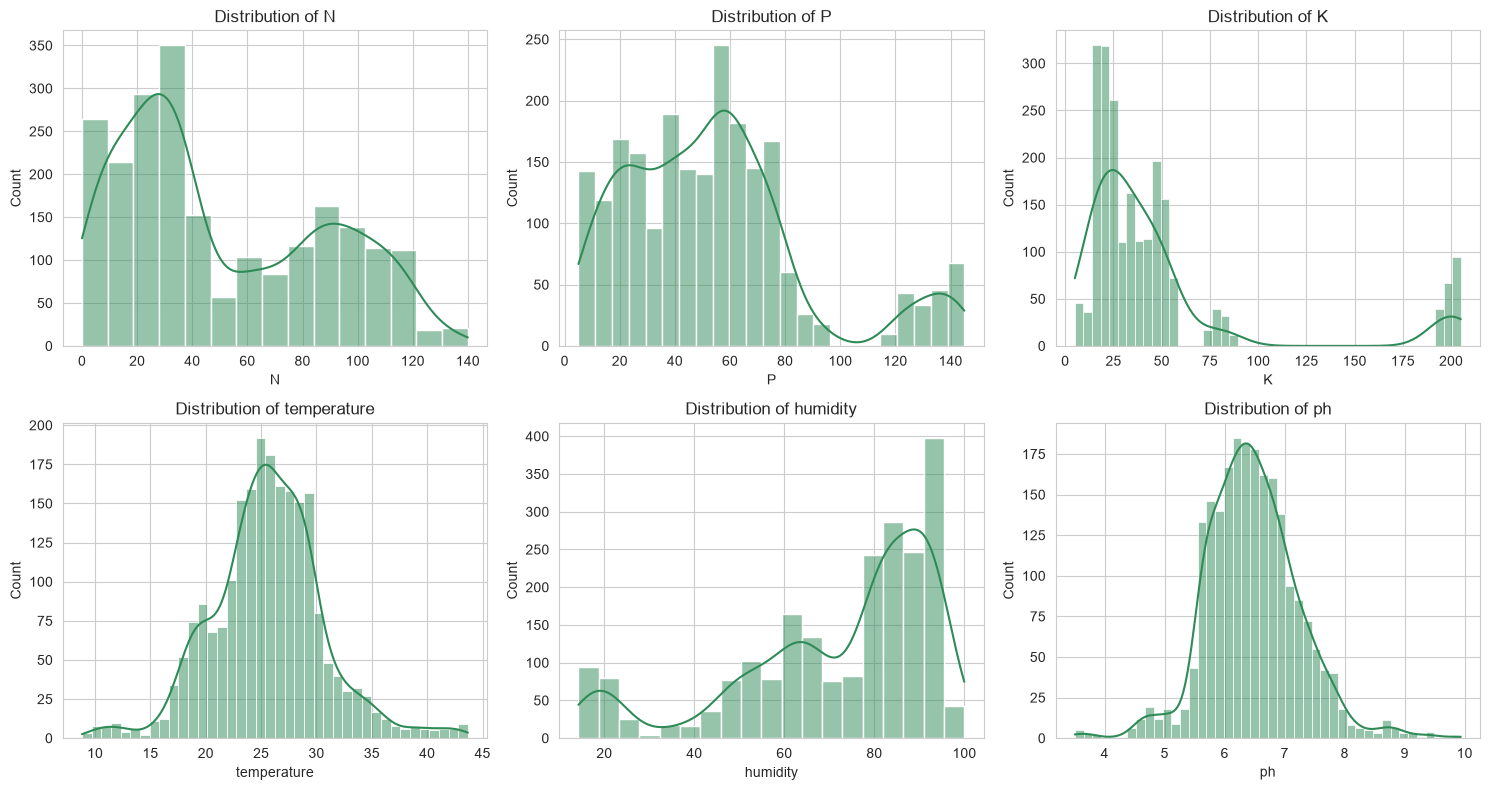

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph']
for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df[col], kde=True, ax=ax, color='seagreen')
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

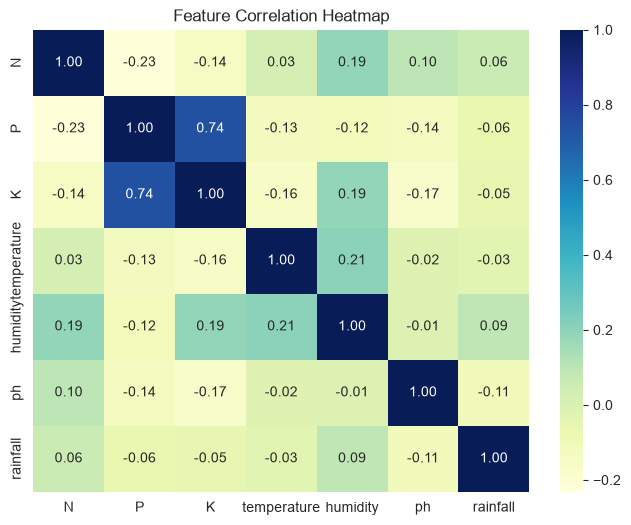

In [9]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[['N','P','K','temperature','humidity','ph','rainfall']].corr(),
            annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

In [10]:
crop_ideal = df.groupby('label')[['N', 'P', 'K']].mean()
crop_ideal.columns = ['N_ideal', 'P_ideal', 'K_ideal']
crop_ideal.head()

,N_ideal,P_ideal,K_ideal
label,,,
apple,20.80,134.22,199.89
banana,100.23,82.01,50.05
blackgram,40.02,67.47,19.24
chickpea,40.09,67.79,79.92
coconut,21.98,16.93,30.59


In [11]:
df = df.merge(crop_ideal, on='label')

df['N_diff'] = df['N'] - df['N_ideal']
df['P_diff'] = df['P'] - df['P_ideal']
df['K_diff'] = df['K'] - df['K_ideal']

df[['label', 'N', 'N_ideal', 'N_diff', 'P', 'P_ideal', 'P_diff', 'K', 'K_ideal', 'K_diff']].head()

,label,N,N_ideal,N_diff,P,P_ideal,P_diff,K,K_ideal,K_diff
0,rice,90,79.89,10.11,42,47.58,-5.58,43,39.87,3.13
1,rice,85,79.89,5.11,58,47.58,10.42,41,39.87,1.13
2,rice,60,79.89,-19.89,55,47.58,7.42,44,39.87,4.13
3,rice,74,79.89,-5.89,35,47.58,-12.58,40,39.87,0.13
4,rice,78,79.89,-1.89,42,47.58,-5.58,42,39.87,2.13


In [12]:
def recommend_fertilizer(row, threshold=5):
    diffs = {'N': row['N_diff'], 'P': row['P_diff'], 'K': row['K_diff']}
    worst_nutrient = min(diffs, key=diffs.get)
    worst_value = diffs[worst_nutrient]

    if worst_value >= -threshold:
        return 'Well Fertilized'
    elif worst_nutrient == 'N':
        return 'Urea'
    elif worst_nutrient == 'P':
        return 'DAP'
    else:
        return 'MOP'

df['Fertilizer'] = df.apply(recommend_fertilizer, axis=1)
df['Fertilizer'].value_counts()

Fertilizer
Well Fertilized    890
Urea               767
DAP                510
MOP                 33
Name: count, dtype: int64

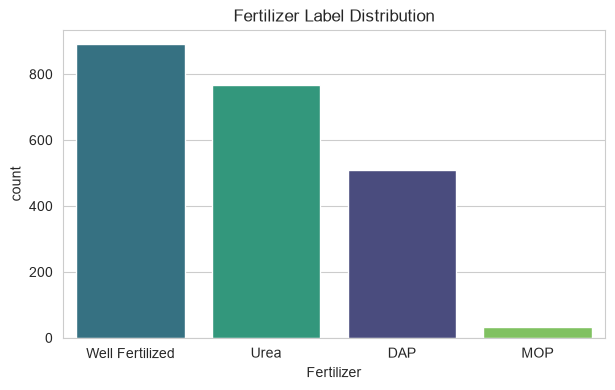

In [13]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='Fertilizer', hue='Fertilizer', order=df['Fertilizer'].value_counts().index,
              palette='viridis', legend=False)
plt.title('Fertilizer Label Distribution')
plt.show()

In [14]:
le_crop = LabelEncoder()
df['crop_encoded'] = le_crop.fit_transform(df['label'])

le_fert = LabelEncoder()
df['fertilizer_encoded'] = le_fert.fit_transform(df['Fertilizer'])

print("Crop mapping:", dict(zip(le_crop.classes_, le_crop.transform(le_crop.classes_))))
print()
print("Fertilizer mapping:", dict(zip(le_fert.classes_, le_fert.transform(le_fert.classes_))))

Crop mapping: {'apple': np.int64(0), 'banana': np.int64(1), 'blackgram': np.int64(2), 'chickpea': np.int64(3), 'coconut': np.int64(4), 'coffee': np.int64(5), 'cotton': np.int64(6), 'grapes': np.int64(7), 'jute': np.int64(8), 'kidneybeans': np.int64(9), 'lentil': np.int64(10), 'maize': np.int64(11), 'mango': np.int64(12), 'mothbeans': np.int64(13), 'mungbean': np.int64(14), 'muskmelon': np.int64(15), 'orange': np.int64(16), 'papaya': np.int64(17), 'pigeonpeas': np.int64(18), 'pomegranate': np.int64(19), 'rice': np.int64(20), 'watermelon': np.int64(21)}

Fertilizer mapping: {'DAP': np.int64(0), 'MOP': np.int64(1), 'Urea': np.int64(2), 'Well Fertilized': np.int64(3)}


In [15]:
feature_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'crop_encoded']
X = df[feature_cols]
y = df['fertilizer_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1760, 8)
Test shape: (440, 8)


In [16]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
}

results = {}
for name, model in models.items():
    if name in ['KNN', 'SVM']:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"{name}: {acc:.4f}")

Decision Tree: 0.9432
Random Forest: 0.9432
KNN: 0.6932
SVM: 0.6977


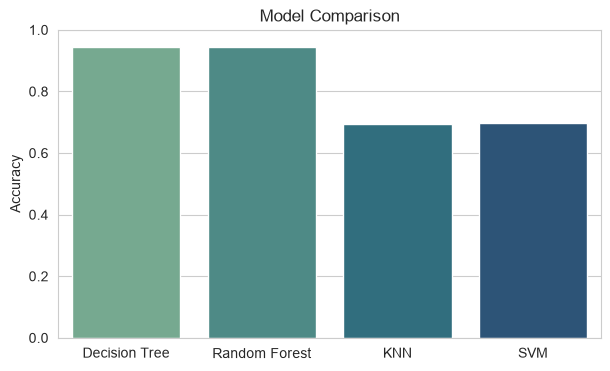

In [18]:
plt.figure(figsize=(7, 4))
sns.barplot(x=list(results.keys()), y=list(results.values()), hue=list(results.keys()),
            palette='crest', legend=False)
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1)
plt.show()

In [19]:
best_model = RandomForestClassifier(n_estimators=200, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=le_fert.classes_))

Accuracy: 0.9431818181818182

                 precision    recall  f1-score   support

            DAP       0.96      0.94      0.95       102
            MOP       1.00      0.14      0.25         7
           Urea       0.94      0.96      0.95       153
Well Fertilized       0.93      0.96      0.95       178

       accuracy                           0.94       440
      macro avg       0.96      0.75      0.77       440
   weighted avg       0.94      0.94      0.94       440



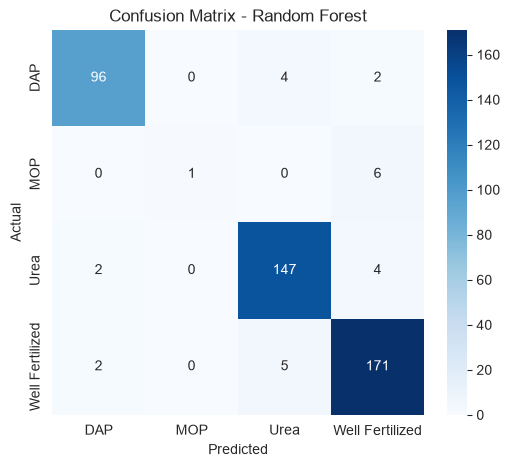

In [20]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fert.classes_, yticklabels=le_fert.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()

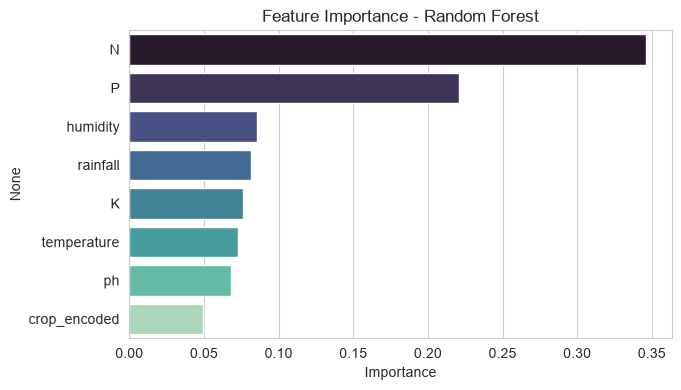

N               0.346065
P               0.220658
humidity        0.085509
rainfall        0.081640
K               0.075887
temperature     0.072669
ph              0.068210
crop_encoded    0.049363
dtype: float64

In [21]:
importances = pd.Series(best_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=importances.values, y=importances.index, hue=importances.index,
            palette='mako', legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()
importances

In [22]:
joblib.dump(best_model, 'fertilizer_model.pkl')
joblib.dump(le_crop, 'crop_encoder.pkl')
joblib.dump(le_fert, 'fertilizer_encoder.pkl')
print("Saved: fertilizer_model.pkl, crop_encoder.pkl, fertilizer_encoder.pkl")

Saved: fertilizer_model.pkl, crop_encoder.pkl, fertilizer_encoder.pkl


In [23]:
def predict_fertilizer(crop, N, P, K, temperature, humidity, ph, rainfall):
    if crop not in le_crop.classes_:
        return f"Unknown crop '{crop}'. Known crops: {list(le_crop.classes_)}"

    crop_encoded = le_crop.transform([crop])[0]
    input_data = pd.DataFrame([[N, P, K, temperature, humidity, ph, rainfall, crop_encoded]],
                              columns=feature_cols)
    pred_encoded = best_model.predict(input_data)[0]
    pred_label = le_fert.inverse_transform([pred_encoded])[0]
    return pred_label

print(predict_fertilizer('rice', N=40, P=50, K=45, temperature=22, humidity=82, ph=6.5, rainfall=230))
print(predict_fertilizer('coffee', N=100, P=27, K=30, temperature=25, humidity=58, ph=6.8, rainfall=155))

Urea
Well Fertilized


---
# Part 2: Real Fertilizer Dataset (7 Fertilizer Types)

Now using an actual fertilizer dataset with real labels instead of our rule-based approximation.

In [24]:
df2 = pd.read_csv("Fertilizer Prediction.csv")
print("Shape:", df2.shape)
df2.head()

Shape: (99, 9)


,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,26,52,38,Sandy,Maize,37,0,0,Urea
1,29,52,45,Loamy,Sugarcane,12,0,36,DAP
2,34,65,62,Black,Cotton,7,9,30,14-35-14
3,32,62,34,Red,Tobacco,22,0,20,28-28
4,28,54,46,Clayey,Paddy,35,0,0,Urea


In [25]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Temparature      99 non-null     int64
 1   Humidity         99 non-null     int64
 2   Moisture         99 non-null     int64
 3   Soil Type        99 non-null     str  
 4   Crop Type        99 non-null     str  
 5   Nitrogen         99 non-null     int64
 6   Potassium        99 non-null     int64
 7   Phosphorous      99 non-null     int64
 8   Fertilizer Name  99 non-null     str  
dtypes: int64(6), str(3)
memory usage: 8.7 KB


In [26]:
df2.isnull().sum()

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64

In [27]:
print("Soil types:", df2['Soil Type'].unique())
print("Crop types:", df2['Crop Type'].unique())
print()
print(df2['Fertilizer Name'].value_counts())

Soil types: <ArrowStringArray>
['Sandy', 'Loamy', 'Black', 'Red', 'Clayey']
Length: 5, dtype: str
Crop types: <ArrowStringArray>
[      'Maize',   'Sugarcane',      'Cotton',     'Tobacco',       'Paddy',
      'Barley',       'Wheat',     'Millets',   'Oil seeds',      'Pulses',
 'Ground Nuts']
Length: 11, dtype: str

Fertilizer Name
Urea        22
DAP         18
28-28       17
14-35-14    14
20-20       14
17-17-17     7
10-26-26     7
Name: count, dtype: int64


In [28]:
le_soil = LabelEncoder()
df2['soil_encoded'] = le_soil.fit_transform(df2['Soil Type'])

le_crop2 = LabelEncoder()
df2['crop_encoded2'] = le_crop2.fit_transform(df2['Crop Type'])

le_fert2 = LabelEncoder()
df2['fertilizer_encoded2'] = le_fert2.fit_transform(df2['Fertilizer Name'])

print("Soil mapping:", dict(zip(le_soil.classes_, le_soil.transform(le_soil.classes_))))
print()
print("Crop mapping:", dict(zip(le_crop2.classes_, le_crop2.transform(le_crop2.classes_))))
print()
print("Fertilizer mapping:", dict(zip(le_fert2.classes_, le_fert2.transform(le_fert2.classes_))))

Soil mapping: {'Black': np.int64(0), 'Clayey': np.int64(1), 'Loamy': np.int64(2), 'Red': np.int64(3), 'Sandy': np.int64(4)}

Crop mapping: {'Barley': np.int64(0), 'Cotton': np.int64(1), 'Ground Nuts': np.int64(2), 'Maize': np.int64(3), 'Millets': np.int64(4), 'Oil seeds': np.int64(5), 'Paddy': np.int64(6), 'Pulses': np.int64(7), 'Sugarcane': np.int64(8), 'Tobacco': np.int64(9), 'Wheat': np.int64(10)}

Fertilizer mapping: {'10-26-26': np.int64(0), '14-35-14': np.int64(1), '17-17-17': np.int64(2), '20-20': np.int64(3), '28-28': np.int64(4), 'DAP': np.int64(5), 'Urea': np.int64(6)}


In [29]:
feature_cols2 = ['Temparature', 'Humidity ', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous', 'soil_encoded', 'crop_encoded2']
X2 = df2[feature_cols2]
y2 = df2['fertilizer_encoded2']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

print("Train shape:", X_train2.shape)
print("Test shape:", X_test2.shape)

Train shape: (79, 8)
Test shape: (20, 8)


In [30]:
scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

In [31]:
models2 = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'SVM': SVC(kernel='rbf', random_state=42),
}

results2 = {}
for name, model in models2.items():
    if name in ['KNN', 'SVM']:
        model.fit(X_train2_scaled, y_train2)
        preds = model.predict(X_test2_scaled)
    else:
        model.fit(X_train2, y_train2)
        preds = model.predict(X_test2)
    acc = accuracy_score(y_test2, preds)
    results2[name] = acc
    print(f"{name}: {acc:.4f}")

Decision Tree: 0.9500
Random Forest: 1.0000
KNN: 0.9000
SVM: 1.0000


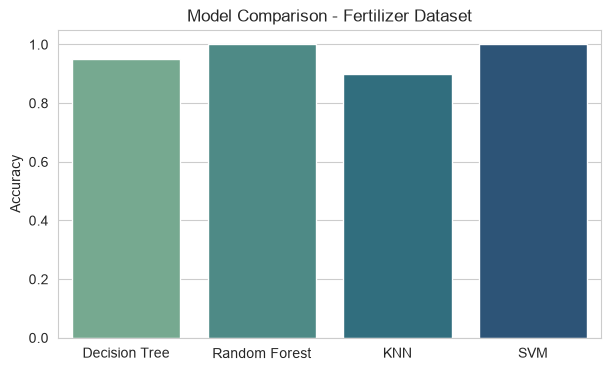

In [32]:
plt.figure(figsize=(7, 4))
sns.barplot(x=list(results2.keys()), y=list(results2.values()), hue=list(results2.keys()),
            palette='crest', legend=False)
plt.ylabel('Accuracy')
plt.title('Model Comparison - Fertilizer Dataset')
plt.ylim(0, 1.05)
plt.show()

In [33]:
from sklearn.model_selection import cross_val_score

rf_for_cv = RandomForestClassifier(n_estimators=200, random_state=42)
cv_scores = cross_val_score(rf_for_cv, X2, y2, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average accuracy:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())

Cross-validation scores: [1.   1.   1.   0.95 1.  ]
Average accuracy: 0.99
Standard deviation: 0.020000000000000018


In [34]:
best_model2 = RandomForestClassifier(n_estimators=200, random_state=42)
best_model2.fit(X_train2, y_train2)
y_pred2 = best_model2.predict(X_test2)

print("Accuracy:", accuracy_score(y_test2, y_pred2))
print()
print(classification_report(y_test2, y_pred2, target_names=le_fert2.classes_))

Accuracy: 1.0

              precision    recall  f1-score   support

    10-26-26       1.00      1.00      1.00         1
    14-35-14       1.00      1.00      1.00         3
    17-17-17       1.00      1.00      1.00         1
       20-20       1.00      1.00      1.00         3
       28-28       1.00      1.00      1.00         3
         DAP       1.00      1.00      1.00         4
        Urea       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



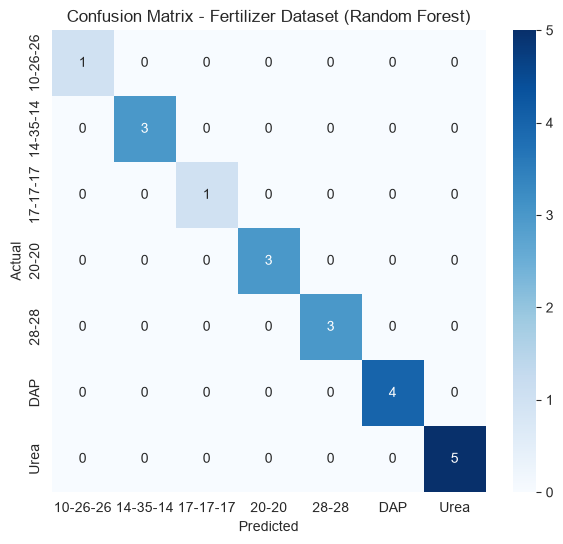

In [35]:
cm2 = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(7, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_fert2.classes_, yticklabels=le_fert2.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Fertilizer Dataset (Random Forest)')
plt.show()

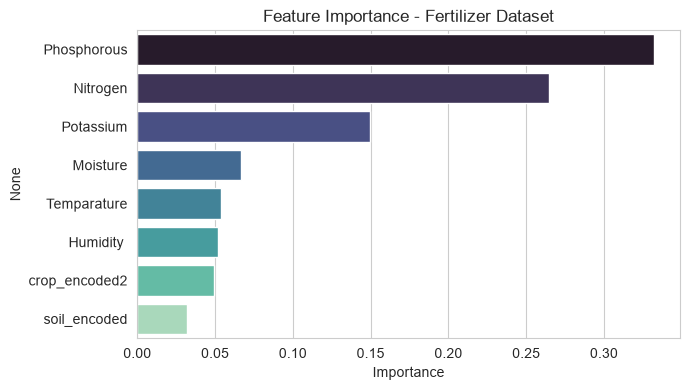

Phosphorous      0.332143
Nitrogen         0.264607
Potassium        0.149528
Moisture         0.066566
Temparature      0.053868
Humidity         0.051982
crop_encoded2    0.049403
soil_encoded     0.031902
dtype: float64

In [36]:
importances2 = pd.Series(best_model2.feature_importances_, index=feature_cols2).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=importances2.values, y=importances2.index, hue=importances2.index,
            palette='mako', legend=False)
plt.title('Feature Importance - Fertilizer Dataset')
plt.xlabel('Importance')
plt.show()
importances2

In [37]:
joblib.dump(best_model2, 'fertilizer_model_v2.pkl')
joblib.dump(le_soil, 'soil_encoder.pkl')
joblib.dump(le_crop2, 'crop_encoder_v2.pkl')
joblib.dump(le_fert2, 'fertilizer_encoder_v2.pkl')
print("Saved Part 2 model and encoders.")

Saved Part 2 model and encoders.


In [38]:
def predict_fertilizer_v2(soil_type, crop_type, temperature, humidity, moisture, nitrogen, potassium, phosphorous):
    if soil_type not in le_soil.classes_:
        return f"Unknown soil type '{soil_type}'. Known: {list(le_soil.classes_)}"
    if crop_type not in le_crop2.classes_:
        return f"Unknown crop '{crop_type}'. Known: {list(le_crop2.classes_)}"

    soil_encoded = le_soil.transform([soil_type])[0]
    crop_encoded = le_crop2.transform([crop_type])[0]

    input_data = pd.DataFrame(
        [[temperature, humidity, moisture, nitrogen, potassium, phosphorous, soil_encoded, crop_encoded]],
        columns=feature_cols2
    )
    pred_encoded = best_model2.predict(input_data)[0]
    pred_label = le_fert2.inverse_transform([pred_encoded])[0]
    return pred_label

print(predict_fertilizer_v2('Sandy', 'Maize', temperature=26, humidity=52, moisture=38, nitrogen=37, potassium=0, phosphorous=0))
print(predict_fertilizer_v2('Loamy', 'Sugarcane', temperature=29, humidity=52, moisture=45, nitrogen=12, potassium=0, phosphorous=36))

Urea
DAP


---
# Part 3: Multi-Label Nutrient Deficiency Detection

Instead of predicting a single fertilizer, predict which nutrients (N, P, K) are individually deficient — since real fertilizers often address multiple nutrients at once.

In [39]:
fertilizer_nutrient_map = {
    'Urea':      {'N': 1, 'P': 0, 'K': 0},
    'DAP':       {'N': 1, 'P': 1, 'K': 0},
    'MOP':       {'N': 0, 'P': 0, 'K': 1},
    '14-35-14':  {'N': 1, 'P': 1, 'K': 1},
    '28-28':     {'N': 1, 'P': 1, 'K': 0},
    '17-17-17':  {'N': 1, 'P': 1, 'K': 1},
    '20-20':     {'N': 1, 'P': 1, 'K': 0},
    '10-26-26':  {'N': 1, 'P': 1, 'K': 1},
}

df2['needs_N'] = df2['Fertilizer Name'].map(lambda f: fertilizer_nutrient_map[f]['N'])
df2['needs_P'] = df2['Fertilizer Name'].map(lambda f: fertilizer_nutrient_map[f]['P'])
df2['needs_K'] = df2['Fertilizer Name'].map(lambda f: fertilizer_nutrient_map[f]['K'])

df2[['Fertilizer Name', 'needs_N', 'needs_P', 'needs_K']].head(10)

,Fertilizer Name,needs_N,needs_P,needs_K
0,Urea,1,0,0
1,DAP,1,1,0
2,14-35-14,1,1,1
3,28-28,1,1,0
4,Urea,1,0,0
5,17-17-17,1,1,1
6,20-20,1,1,0
7,Urea,1,0,0
8,28-28,1,1,0
9,14-35-14,1,1,1


In [40]:
from sklearn.multioutput import MultiOutputClassifier

X_multi = df2[['Temparature', 'Humidity ', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous', 'soil_encoded', 'crop_encoded2']]
y_multi = df2[['needs_N', 'needs_P', 'needs_K']]

X_multi_train, X_multi_test, y_multi_train, y_multi_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print("Train shape:", X_multi_train.shape, y_multi_train.shape)
print("Test shape:", X_multi_test.shape, y_multi_test.shape)

Train shape: (79, 8) (79, 3)
Test shape: (20, 8) (20, 3)


In [41]:
multi_model = MultiOutputClassifier(RandomForestClassifier(n_estimators=200, random_state=42))
multi_model.fit(X_multi_train, y_multi_train)

y_multi_pred = multi_model.predict(X_multi_test)
y_multi_pred_df = pd.DataFrame(y_multi_pred, columns=['needs_N', 'needs_P', 'needs_K'])
y_multi_pred_df.head()

,needs_N,needs_P,needs_K
0,1,1,0
1,1,1,0
2,1,1,1
3,1,0,0
4,1,1,0


In [42]:
from sklearn.metrics import hamming_loss, accuracy_score

# Hamming loss: fraction of individual labels (N/P/K) that were predicted wrong, across all rows
h_loss = hamming_loss(y_multi_test, y_multi_pred)
print("Hamming Loss:", h_loss)

# Exact match: fraction of rows where ALL THREE labels were predicted correctly
exact_match = accuracy_score(y_multi_test, y_multi_pred)
print("Exact Match Accuracy:", exact_match)

# Per-nutrient accuracy
for i, nutrient in enumerate(['N', 'P', 'K']):
    acc = accuracy_score(y_multi_test.iloc[:, i], y_multi_pred[:, i])
    print(f"Accuracy for needs_{nutrient}: {acc:.4f}")

Hamming Loss: 0.0
Exact Match Accuracy: 1.0
Accuracy for needs_N: 1.0000
Accuracy for needs_P: 1.0000
Accuracy for needs_K: 1.0000


---
# Part 4: Dosage Estimation (Regression)

**Important caveat:** This dataset has no real-world "kg of fertilizer applied" measurements. The dosage figures below are **engineered estimates** based on standard fertilizer nutrient-content percentages (e.g. Urea is ~46% nitrogen) combined with each field's nutrient deficiency — not verified agronomic data. This is included to demonstrate a regression pipeline on top of our classification work, not as real fertilizer application guidance.

In [43]:
# Real-world approximate nutrient content of each fertilizer (% by weight)
fertilizer_nutrient_content = {
    'Urea':      {'N': 0.46, 'P': 0.00, 'K': 0.00},
    'DAP':       {'N': 0.18, 'P': 0.46, 'K': 0.00},
    'MOP':       {'N': 0.00, 'P': 0.00, 'K': 0.60},
    '14-35-14':  {'N': 0.14, 'P': 0.35, 'K': 0.14},
    '28-28':     {'N': 0.28, 'P': 0.28, 'K': 0.00},
    '17-17-17':  {'N': 0.17, 'P': 0.17, 'K': 0.17},
    '20-20':     {'N': 0.20, 'P': 0.20, 'K': 0.00},
    '10-26-26':  {'N': 0.10, 'P': 0.26, 'K': 0.26},
}

# Crop-level "ideal" nutrient values, same approach as Part 1
crop_ideal2 = df2.groupby('Crop Type')[['Nitrogen', 'Phosphorous', 'Potassium']].mean()
crop_ideal2.columns = ['N_ideal2', 'P_ideal2', 'K_ideal2']
crop_ideal2.head()

,N_ideal2,P_ideal2,K_ideal2
Crop Type,,,
Barley,12.571429,26.000000,5.285714
Cotton,16.416667,23.833333,3.333333
Ground Nuts,23.285714,21.571429,2.000000
Maize,18.333333,18.666667,5.666667
Millets,23.181818,14.363636,0.000000


In [44]:
def estimate_dosage(row):
    crop = row['Crop Type']
    fert = row['Fertilizer Name']

    ideal = crop_ideal2.loc[crop]
    n_deficit = max(0, ideal['N_ideal2'] - row['Nitrogen'])
    p_deficit = max(0, ideal['P_ideal2'] - row['Phosphorous'])
    k_deficit = max(0, ideal['K_ideal2'] - row['Potassium'])

    content = fertilizer_nutrient_content[fert]

    # Total nutrient deficit this fertilizer needs to cover, weighted by what it actually supplies
    nutrient_needed = (n_deficit * content['N']) + (p_deficit * content['P']) + (k_deficit * content['K'])

    # Convert deficit into a kg/hectare estimate
    # (using a simplified conversion factor since we lack real field-size / uptake-rate data)
    dosage_kg_per_hectare = nutrient_needed * 2.5

    return round(dosage_kg_per_hectare, 1)

df2['estimated_dosage_kg_ha'] = df2.apply(estimate_dosage, axis=1)
df2[['Crop Type', 'Fertilizer Name', 'Nitrogen', 'Phosphorous', 'Potassium', 'estimated_dosage_kg_ha']].head(10)

,Crop Type,Fertilizer Name,Nitrogen,Phosphorous,Potassium,estimated_dosage_kg_ha
0,Maize,Urea,37,0,0,0.0
1,Sugarcane,DAP,12,36,0,1.2
2,Cotton,14-35-14,7,30,9,3.3
3,Tobacco,28-28,22,20,0,0.0
4,Paddy,Urea,35,0,0,0.0
5,Barley,17-17-17,12,13,10,5.8
6,Cotton,20-20,9,10,0,10.6
7,Wheat,Urea,41,0,0,0.0
8,Millets,28-28,21,18,0,1.5
9,Oil seeds,14-35-14,9,30,7,3.5


In [45]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Reuse the same feature set as our classification model, plus which fertilizer was chosen
X_dosage = df2[['Temparature', 'Humidity ', 'Moisture', 'Nitrogen', 'Potassium', 'Phosphorous', 'soil_encoded', 'crop_encoded2', 'fertilizer_encoded2']]
y_dosage = df2['estimated_dosage_kg_ha']

X_dosage_train, X_dosage_test, y_dosage_train, y_dosage_test = train_test_split(
    X_dosage, y_dosage, test_size=0.2, random_state=42
)

dosage_model = RandomForestRegressor(n_estimators=200, random_state=42)
dosage_model.fit(X_dosage_train, y_dosage_train)

dosage_preds = dosage_model.predict(X_dosage_test)

mae = mean_absolute_error(y_dosage_test, dosage_preds)
r2 = r2_score(y_dosage_test, dosage_preds)
print(f"Mean Absolute Error: {mae:.2f} kg/ha")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: 0.87 kg/ha
R² Score: 0.5943


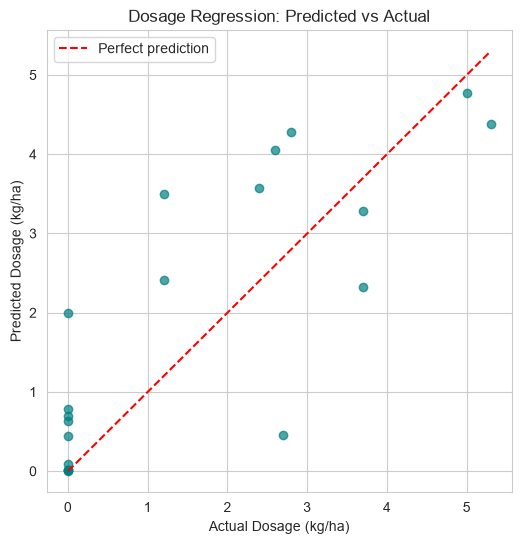

In [46]:
plt.figure(figsize=(6, 6))
plt.scatter(y_dosage_test, dosage_preds, alpha=0.7, color='teal')
max_val = max(y_dosage_test.max(), dosage_preds.max())
plt.plot([0, max_val], [0, max_val], 'r--', label='Perfect prediction')
plt.xlabel('Actual Dosage (kg/ha)')
plt.ylabel('Predicted Dosage (kg/ha)')
plt.title('Dosage Regression: Predicted vs Actual')
plt.legend()
plt.show()

In [47]:
joblib.dump(dosage_model, 'dosage_model.pkl')
print("Dosage model saved.")

Dosage model saved.


---
# Part 5: Confidence-Aware Fertilizer Recommendations

Instead of always giving a single confident answer, show prediction probabilities and flag low-confidence cases for manual review.

In [48]:
probs = best_model2.predict_proba(X_test2)
proba_df = pd.DataFrame(probs, columns=le_fert2.classes_)
proba_df.head()

,10-26-26,14-35-14,17-17-17,20-20,28-28,DAP,Urea
0,0.015,0.79,0.110,0.025,0.010,0.045,0.005
1,0.000,0.00,0.000,0.005,0.000,0.000,0.995
2,0.145,0.07,0.625,0.080,0.020,0.045,0.015
3,0.195,0.57,0.055,0.015,0.055,0.085,0.025
4,0.020,0.06,0.105,0.640,0.055,0.100,0.020


In [49]:
def predict_fertilizer_with_confidence(soil_type, crop_type, temperature, humidity, moisture,
                                        nitrogen, potassium, phosphorous, confidence_threshold=0.6):
    soil_encoded = le_soil.transform([soil_type])[0]
    crop_encoded = le_crop2.transform([crop_type])[0]

    input_data = pd.DataFrame(
        [[temperature, humidity, moisture, nitrogen, potassium, phosphorous, soil_encoded, crop_encoded]],
        columns=feature_cols2
    )

    proba = best_model2.predict_proba(input_data)[0]
    top_idx = proba.argmax()
    top_fertilizer = le_fert2.classes_[top_idx]
    top_confidence = proba[top_idx]

    result = {
        'recommended_fertilizer': top_fertilizer,
        'confidence': round(top_confidence, 3),
        'flagged_for_review': top_confidence < confidence_threshold
    }

    # Show top 3 alternatives too, for transparency
    top3_idx = proba.argsort()[::-1][:3]
    result['top_3_options'] = [
        (le_fert2.classes_[i], round(proba[i], 3)) for i in top3_idx
    ]

    return result

# Test with a confident case and a potentially ambiguous one
print(predict_fertilizer_with_confidence('Sandy', 'Maize', temperature=26, humidity=52, moisture=38, nitrogen=37, potassium=0, phosphorous=0))
print()
print(predict_fertilizer_with_confidence('Black', 'Cotton', temperature=30, humidity=60, moisture=50, nitrogen=20, potassium=15, phosphorous=15))

{'recommended_fertilizer': 'Urea', 'confidence': np.float64(0.895), 'flagged_for_review': np.False_, 'top_3_options': [('Urea', np.float64(0.895)), ('28-28', np.float64(0.045)), ('20-20', np.float64(0.045))]}

{'recommended_fertilizer': '17-17-17', 'confidence': np.float64(0.405), 'flagged_for_review': np.True_, 'top_3_options': [('17-17-17', np.float64(0.405)), ('28-28', np.float64(0.35)), ('10-26-26', np.float64(0.105))]}


---
# Part 6: Cost & Sustainability-Aware Recommendation

**Note:** Prices and environmental impact scores below are illustrative example values for demonstrating the decision-optimization concept — not sourced from real market or environmental data. Real deployment would require actual regional pricing and validated environmental impact metrics.

In [50]:
# Illustrative example values (₹ per kg, and a 1-10 environmental impact score, 10 = most harmful runoff risk)
fertilizer_profile = {
    'Urea':      {'price_per_kg': 6,  'env_impact': 7},
    'DAP':       {'price_per_kg': 27, 'env_impact': 6},
    'MOP':       {'price_per_kg': 17, 'env_impact': 4},
    '14-35-14':  {'price_per_kg': 30, 'env_impact': 5},
    '28-28':     {'price_per_kg': 24, 'env_impact': 6},
    '17-17-17':  {'price_per_kg': 28, 'env_impact': 4},
    '20-20':     {'price_per_kg': 22, 'env_impact': 6},
    '10-26-26':  {'price_per_kg': 26, 'env_impact': 5},
}

profile_df = pd.DataFrame(fertilizer_profile).T
profile_df.columns = ['price_per_kg', 'env_impact']
profile_df

,price_per_kg,env_impact
Urea,6,7
DAP,27,6
MOP,17,4
14-35-14,30,5
28-28,24,6
17-17-17,28,4
20-20,22,6
10-26-26,26,5


In [51]:
def recommend_with_cost_sustainability(soil_type, crop_type, temperature, humidity, moisture,
                                        nitrogen, potassium, phosphorous, priority='balanced'):
    result = predict_fertilizer_with_confidence(soil_type, crop_type, temperature, humidity,
                                                  moisture, nitrogen, potassium, phosphorous)

    # Score each of the top 3 viable options by price, sustainability, or a balance of both
    scored_options = []
    for fert_name, ml_confidence in result['top_3_options']:
        profile = fertilizer_profile[fert_name]
        if priority == 'cost':
            score = profile['price_per_kg']
        elif priority == 'sustainability':
            score = profile['env_impact']
        else:  # balanced: weigh ML confidence, price, and environmental impact together
            normalized_price = profile['price_per_kg'] / 30
            normalized_impact = profile['env_impact'] / 10
            score = (1 - ml_confidence) + normalized_price + normalized_impact

        scored_options.append({
            'fertilizer': fert_name,
            'ml_confidence': ml_confidence,
            'price_per_kg': profile['price_per_kg'],
            'env_impact': profile['env_impact'],
            'score': round(score, 3)
        })

    scored_options.sort(key=lambda x: x['score'])
    return scored_options

# Try all three priority modes on the same field
for priority in ['balanced', 'cost', 'sustainability']:
    print(f"--- Priority: {priority} ---")
    for option in recommend_with_cost_sustainability('Sandy', 'Maize', temperature=26, humidity=52,
                                                       moisture=38, nitrogen=37, potassium=0,
                                                       phosphorous=0, priority=priority):
        print(option)
    print()

--- Priority: balanced ---
{'fertilizer': 'Urea', 'ml_confidence': np.float64(0.895), 'price_per_kg': 6, 'env_impact': 7, 'score': np.float64(1.005)}
{'fertilizer': '20-20', 'ml_confidence': np.float64(0.045), 'price_per_kg': 22, 'env_impact': 6, 'score': np.float64(2.288)}
{'fertilizer': '28-28', 'ml_confidence': np.float64(0.045), 'price_per_kg': 24, 'env_impact': 6, 'score': np.float64(2.355)}

--- Priority: cost ---
{'fertilizer': 'Urea', 'ml_confidence': np.float64(0.895), 'price_per_kg': 6, 'env_impact': 7, 'score': 6}
{'fertilizer': '20-20', 'ml_confidence': np.float64(0.045), 'price_per_kg': 22, 'env_impact': 6, 'score': 22}
{'fertilizer': '28-28', 'ml_confidence': np.float64(0.045), 'price_per_kg': 24, 'env_impact': 6, 'score': 24}

--- Priority: sustainability ---
{'fertilizer': '28-28', 'ml_confidence': np.float64(0.045), 'price_per_kg': 24, 'env_impact': 6, 'score': 6}
{'fertilizer': '20-20', 'ml_confidence': np.float64(0.045), 'price_per_kg': 22, 'env_impact': 6, 'score': 

---
# Part 7: Explainability with SHAP

Understanding *why* the model made a specific recommendation, not just what it recommended.

In [52]:
import shap

explainer = shap.TreeExplainer(best_model2)
shap_values = explainer.shap_values(X_test2)

print("SHAP values shape:", np.array(shap_values).shape)

c:\Users\Swathi\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP values shape: (20, 8, 7)


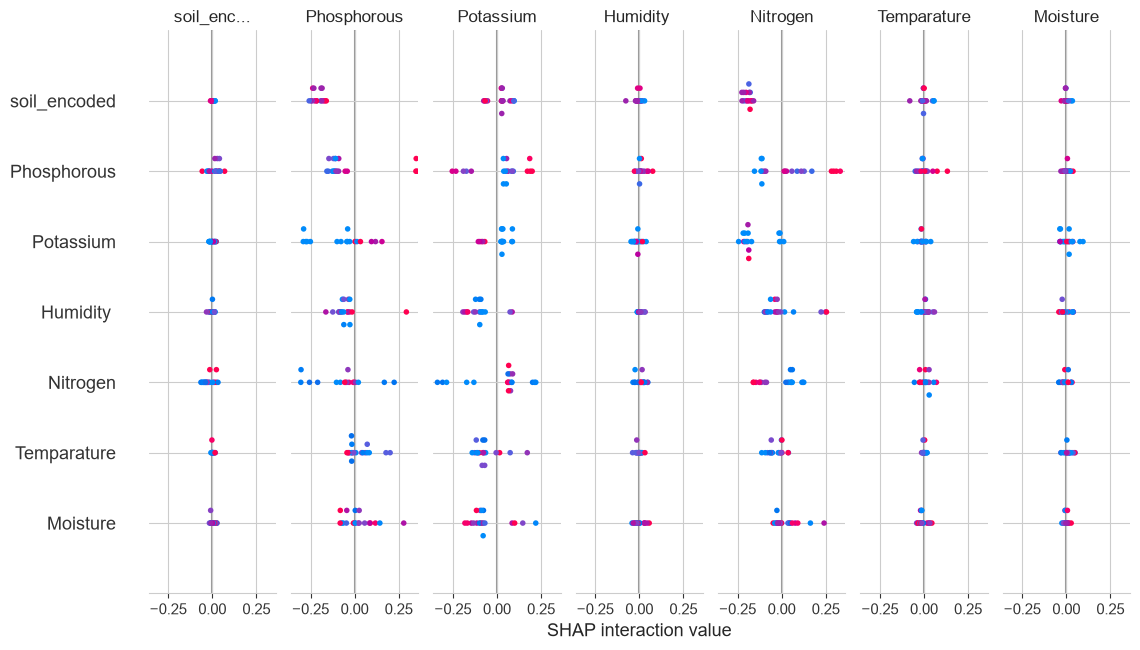

In [53]:
shap.summary_plot(shap_values, X_test2, feature_names=feature_cols2, class_names=le_fert2.classes_, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=100, bbox_inches='tight')
plt.show()

In [54]:
sample_idx = 0  # first test sample — change this to explore others
sample = X_test2.iloc[sample_idx]
actual_fertilizer = le_fert2.classes_[y_test2.iloc[sample_idx]]
predicted_fertilizer = le_fert2.classes_[y_pred2[sample_idx]]

print(f"Actual fertilizer: {actual_fertilizer}")
print(f"Predicted fertilizer: {predicted_fertilizer}")
print()
print("Input values for this sample:")
print(sample)

# Get the SHAP values specifically for the predicted class
class_idx = list(le_fert2.classes_).index(predicted_fertilizer)
sample_shap_values = shap_values[sample_idx, :, class_idx]

shap_explanation = pd.DataFrame({
    'feature': feature_cols2,
    'value': sample.values,
    'shap_impact': sample_shap_values
}).sort_values('shap_impact', key=abs, ascending=False)

print()
print(f"Why the model predicted '{predicted_fertilizer}' for this sample:")
shap_explanation

Actual fertilizer: 14-35-14
Predicted fertilizer: 14-35-14

Input values for this sample:
Temparature      30
Humidity         60
Moisture         63
Nitrogen          9
Potassium         9
Phosphorous      29
soil_encoded      3
crop_encoded2     1
Name: 26, dtype: int64

Why the model predicted '14-35-14' for this sample:


,feature,value,shap_impact
4,Potassium,9,0.289031
5,Phosphorous,29,0.191984
3,Nitrogen,9,0.124520
1,Humidity,60,0.033322
0,Temparature,30,0.029759
6,soil_encoded,3,-0.016504
7,crop_encoded2,1,0.007052
2,Moisture,63,-0.005684
